In [17]:
!pip install kagglehub transformers accelerate nltk huggingface_hub


In [1]:
import os
import json
import random
import torch
import kagglehub
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split

from transformers import BlipProcessor, BlipForConditionalGeneration
from torch.optim import AdamW
from nltk.translate.bleu_score import sentence_bleu
from huggingface_hub import login


In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("sumanpaul14/ucm-captioning-dataset")

print("REAL PATH:", path)


REAL PATH: /kaggle/input/datasets/sumanpaul14/ucm-captioning-dataset


In [3]:
DATA_JSON = os.path.join(path, "dataset.json")
IMG_DIR = os.path.join(path, "imgs", "imgs")

In [4]:
print(os.listdir(IMG_DIR)[:10])

['1259.tif', '659.tif', '274.tif', '315.tif', '919.tif', '2037.tif', '1819.tif', '1938.tif', '948.tif', '123.tif']


In [5]:
samples = []

with open(DATA_JSON) as f:
    data = json.load(f)

for item in data["images"]:
    img_path = os.path.join(IMG_DIR, item["filename"])

    if os.path.exists(img_path):
        for sent in item["sentences"]:
            samples.append({
                "image": img_path,
                "caption": sent["raw"]
            })

print("✅ Total samples:", len(samples))

✅ Total samples: 10500


In [6]:
samples = samples[:]   

In [7]:
print(samples[0]["image"])
print(os.path.exists(samples[0]["image"]))

/kaggle/input/datasets/sumanpaul14/ucm-captioning-dataset/imgs/imgs/1.tif
True


In [8]:
class UCMCaptionDataset(Dataset):
    def __init__(self, samples, processor):
        self.samples = samples
        self.processor = processor

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]

        try:
            image = Image.open(item["image"]).convert("RGB").resize((224, 224))
        except:
            return self.__getitem__((idx + 1) % len(self.samples))

        caption = item["caption"]

        encoding = self.processor(
            images=image,
            text=caption,
            padding="max_length",
            truncation=True,
            max_length=20,  
            return_tensors="pt"
        )

        encoding = {k: v.squeeze(0) for k, v in encoding.items()}
        encoding["labels"] = encoding["input_ids"]

        return encoding

In [9]:


device = "cuda" if torch.cuda.is_available() else "cpu"




In [10]:
from transformers import BlipProcessor, BlipForConditionalGeneration

# 1. Load the processor from the official Salesforce repo
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

# 2. Load the actual model weights from the custom repo
model = BlipForConditionalGeneration.from_pretrained("utkarshpise/blip-fedrated_1")

model.to(device)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

In [11]:
dataset = UCMCaptionDataset(samples, processor)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=1)

In [12]:
from torch.cuda.amp import autocast, GradScaler

optimizer = AdamW(model.parameters(), lr=5e-5)

scaler = GradScaler()

EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()

        with autocast():
            outputs = model(**batch)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader)}")

/tmp/ipykernel_55/1365261116.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1:   0%|          | 0/8400 [00:00<?, ?it/s]/tmp/ipykernel_55/1365261116.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1: 100%|██████████| 8400/8400 [29:11<00:00,  4.80it/s, loss=0.233] 


Epoch 1 Loss: 0.43383949088487067


Epoch 2: 100%|██████████| 8400/8400 [29:08<00:00,  4.80it/s, loss=0.577] 


Epoch 2 Loss: 0.3037260533777243


Epoch 3: 100%|██████████| 8400/8400 [29:10<00:00,  4.80it/s, loss=0.171]  

Epoch 3 Loss: 0.2612051712145053


In [13]:

SAVE_PATH = "/kaggle/working/blip_ucm"

model.save_pretrained(SAVE_PATH)
processor.save_pretrained(SAVE_PATH)

print("✅ Model saved at:", SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved at: /kaggle/working/blip_ucm


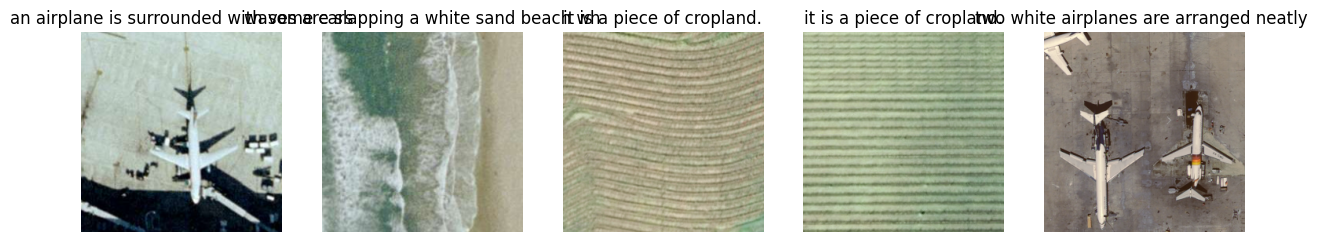

In [14]:
def show_predictions(dataset, num=5):
    model.eval()
    indices = random.sample(range(len(dataset)), num)

    plt.figure(figsize=(15, 8))

    for i, idx in enumerate(indices):
        item = dataset.dataset.samples[idx]

        image = Image.open(item["image"]).convert("RGB")
        inputs = processor(images=image, return_tensors="pt").to(device)

        with torch.no_grad():
            output = model.generate(**inputs, max_length=50, num_beams=5)

        pred = processor.decode(output[0], skip_special_tokens=True)

        plt.subplot(1, num, i+1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(pred[:40])

    plt.show()

show_predictions(test_dataset)



In [19]:
from huggingface_hub import create_repo, upload_folder

repo_name = "divag/blip-ucm-captioning_after_f1"

create_repo(repo_name, exist_ok=True)

upload_folder(
    folder_path=SAVE_PATH,
    repo_id=repo_name,
    repo_type="model"
)

print("Uploaded via folder!")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded via folder!
